## SETUP

In [1]:
!pip install -q -U transformers torchao peft accelerate bitsandbytes trl
!pip install -q    datasets matplotlib nltk sentence-transformers scikit-learn faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.0 MB/s eta 0:00:00


In [2]:
import os, re, random, textwrap, warnings, json
from collections import defaultdict
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.metrics import f1_score
import warnings

warnings.filterwarnings("ignore")
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words("english"))

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Model   : {MODEL_ID}")


PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB
Model   : Qwen/Qwen2.5-1.5B-Instruct


## PHASE 1 — Data Loading & Preprocessing

In [3]:
mts_raw = None
try:
    mts_raw = load_dataset("har1/MTS_Dialogue-Clinical_Note", split="train")
    print(f"MTS-Dialog  : {len(mts_raw)} dialogues")
except Exception as e:
    print(f"MTS-Dialog: {e}")

notechat_raw = None
try:
    notechat_raw = load_dataset("omi-health/medical-dialogue-to-soap-summary", split="train")
    print(f"NoteChat    : {len(notechat_raw)} dialogues")
except Exception as e:
    print(f"NoteChat: {e}")


README.md: 0.00B [00:00, ?B/s]

MTS-Dialog-TrainingSet%20%28SDHP%29.csv: 0.00B [00:00, ?B/s]

(…)Dialog-Validation%20Set%20%28SDHP%29.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1301 [00:00<?, ? examples/s]

MTS-Dialog  : 1301 dialogues


...

test.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/9250 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/250 [00:00<?, ? examples/s]

NoteChat    : 9250 dialogues


In [4]:
PATIENT_SYSTEM = (
    "You are a patient consulting a doctor. "
    "Answer ONLY what you are directly asked — nothing more. "
    "Do NOT mention your diagnosis by name. "
    "Speak in first person, naturally, like a real patient. "
    "Keep answers concise (2-4 sentences)."
)


def make_chatml(system: str, user: str, assistant: str) -> str:
    return (
        f"<|im_start|>system\n{system}<|im_end|>\n"
        f"<|im_start|>user\n{user}<|im_end|>\n"
        f"<|im_start|>assistant\n{assistant}<|im_end|>"
    )


def parse_dialogue(s: str):
    text = re.sub(
        r'\s*(Doctor|Patient|Guest_family|Guest_clinician|Guest):',
        lambda m: f"\n{m.group(1)}:", s.strip()
    )
    turns = []
    for line in text.split("\n"):
        line = line.strip()
        if line.startswith("Doctor:"):
            t = line[7:].strip()
            if t: turns.append(("doctor", t))
        elif line.startswith("Patient:"):
            t = line[8:].strip()
            if t: turns.append(("patient", t))
    return turns


def dialogue_to_pairs(dialogue_str: str, background: str = "",
                       source: str = "") -> list:
    turns  = parse_dialogue(dialogue_str)
    pairs  = []
    system = PATIENT_SYSTEM
    if background:
        system += f"\nBackground: {background}"

    for i in range(len(turns) - 1):
        spk, doc_text   = turns[i]
        nspk, pat_text  = turns[i+1]

        if spk != "doctor" or nspk != "patient":
            continue
        if len(pat_text.split()) < 5:
            continue
        if any(tok in pat_text for tok in ["<|", "<start_of", "</s>", "[INST]"]):
            continue
        if any(pat_text.lower().startswith(p) for p in
               ["the patient", "patient says", "she says", "he says",
                "the doctor", "according to"]):
            continue

        text = make_chatml(
            system=system,
            user=f"Doctor: {doc_text.strip()}",
            assistant=pat_text.strip()
        )
        pairs.append({"text": text, "source": source})

    return pairs


def mts_bg(sec):
    if not sec: return ""
    s = re.search(r'Symptoms:\s*([^\n]+)', sec)
    d = re.search(r'Diagnosis:\s*([^\n]+)', sec)
    parts = []
    if s and "N/A" not in s.group(1): parts.append(s.group(1).strip()[:120])
    if d and "N/A" not in d.group(1): parts.append(d.group(1).strip()[:80])
    return ". ".join(parts)


def notechat_bg(soap):
    m = re.search(r'S:\s*(.+?)(?=O:|$)', soap or "", re.DOTALL)
    return m.group(1).strip().replace("\n", " ")[:200] if m else ""


mts_ex = []
if mts_raw:
    for row in mts_raw:
        d = (row.get("dialogue") or "").strip()
        if d:
            mts_ex.extend(dialogue_to_pairs(d, mts_bg(row.get("section_text","")), "mts"))
    print(f"MTS-Dialog  -> {len(mts_ex)} training pairs")

nc_ex = []
if notechat_raw:
    for row in notechat_raw:
        d = (row.get("dialogue") or "").strip()
        if d:
            nc_ex.extend(dialogue_to_pairs(d, notechat_bg(row.get("soap","")), "notechat"))
    print(f"NoteChat    -> {len(nc_ex)} training pairs")


MAX_TRAIN = 3000
all_train = mts_ex + nc_ex
all_train = [ex for ex in all_train if 100 < len(ex["text"]) < 1800]
random.seed(42)
random.shuffle(all_train)

train_dataset = Dataset.from_list([{"text": ex["text"]} for ex in all_train[:MAX_TRAIN]])
print(f"\nTraining set: {len(train_dataset)} examples")

print("\n" + "-"*60)
print("SAMPLE TRAINING EXAMPLE:")
print("-"*60)
print(train_dataset[0]["text"])
print("-"*60)


MTS-Dialog  -> 3423 training pairs
NoteChat    -> 56902 training pairs

Training set: 3000 examples

------------------------------------------------------------
SAMPLE TRAINING EXAMPLE:
------------------------------------------------------------
<|im_start|>system
You are a patient consulting a doctor. Answer ONLY what you are directly asked — nothing more. Do NOT mention your diagnosis by name. Speak in first person, naturally, like a real patient. Keep answers concise (2-4 sentences).
Background: Patient reports upper abdominal pain, heartburn, and unintentional weight loss of 10 pounds over the past 6 months. No other symptoms such as headache, nasal discharge, cough, chest pain, shortness of<|im_end|>
<|im_start|>user
Doctor: Hello, welcome to the gastroenterology clinic. How can I help you today?<|im_end|>
<|im_start|>assistant
Hi, Doctor. I'm having some upper abdominal pain, heartburn, and I've lost 10 pounds unintentionally over the past 6 months.<|im_end|>
------------------

## PHASE 1B — RAG Symptom Knowledge Base (QuyenAnhDE/Diseases_Symptoms)

In [5]:
# ---------------------------------------------------------------------------
# RAG Symptom Knowledge Base
# Dataset: QuyenAnhDE/Diseases_Symptoms
#   - 400 diseases
#   - Columns: Code, Name, Symptoms (comma-separated string), Treatments
#   - Symptoms are already clean clinical labels — no regex parsing needed
#
# Two components built from this dataset:
#   SYMPTOM_KB   : {disease_name: [symptom, ...]}  — used at case creation
#   TREATMENT_KB : {disease_name: [treatment, ...]} — used in reveal at end
#
# rag_retrieve(disease, question) performs per-turn retrieval:
#   Given the current doctor question, it returns the subset of canonical
#   symptoms most relevant to what the doctor is asking about.
#   This is injected into the system prompt on every turn so the LLM is
#   grounded in the correct disease knowledge for that specific question.
# ---------------------------------------------------------------------------

# ── Load dataset ───────────────────────────────────────────────────────────
ds_raw = None
try:
    ds_raw = load_dataset("QuyenAnhDE/Diseases_Symptoms", split="train")
    print(f"Diseases_Symptoms loaded: {len(ds_raw)} diseases")
except Exception as e:
    print(f"Dataset load failed: {e}")

# ── Build KB dicts ─────────────────────────────────────────────────────────
SYMPTOM_KB   = {}   # disease -> [symptom, ...]
TREATMENT_KB = {}   # disease -> [treatment, ...]

if ds_raw is not None:
    for row in ds_raw:
        name     = (row.get("Name") or "").strip()
        syms_raw = (row.get("Symptoms") or "").strip()
        trts_raw = (row.get("Treatments") or "").strip()
        if not name or not syms_raw:
            continue
        syms = [s.strip() for s in syms_raw.split(",") if s.strip()]
        trts = [t.strip() for t in trts_raw.split(",") if t.strip()] if trts_raw else []
        if len(syms) >= 1:
            SYMPTOM_KB[name]   = syms
            TREATMENT_KB[name] = trts
    print(f"KB built: {len(SYMPTOM_KB)} diseases, {sum(len(v) for v in SYMPTOM_KB.values())} symptoms total")
else:
    # Minimal static fallback
    SYMPTOM_KB = {
        "Pneumonia":        ["Fever", "Productive cough", "Chest pain", "Dyspnoea", "Rigors"],
        "Influenza":        ["Fever", "Myalgia", "Headache", "Dry cough", "Fatigue"],
        "Panic disorder":   ["Palpitations", "Sweating", "Trembling", "Shortness of breath", "Dizziness"],
        "GERD":             ["Heartburn", "Regurgitation", "Chest pain", "Dysphagia", "Hoarseness"],
        "Appendicitis":     ["Abdominal pain", "Nausea", "Vomiting", "Fever", "Loss of appetite"],
    }
    TREATMENT_KB = {}
    print(f"Using static fallback KB: {len(SYMPTOM_KB)} diseases")


# ── Per-turn RAG retrieval ─────────────────────────────────────────────────
# Key words per clinical question category — maps doctor question intent
# to the symptom dimension most relevant to answer.
_Q_KEYWORDS = {
    "onset":       ["when", "start", "began", "long", "ago", "duration", "first"],
    "location":    ["where", "location", "side", "area", "place", "point"],
    "character":   ["describe", "like", "feel", "type", "nature", "kind", "quality"],
    "severity":    ["severe", "bad", "scale", "rate", "mild", "worse", "better", "intensity"],
    "associated":  ["other", "also", "else", "additional", "along", "together"],
    "history":     ["history", "before", "previous", "ever", "past", "background"],
    "aggravating": ["worse", "aggravate", "trigger", "cause", "bring on", "makes it"],
    "relieving":   ["better", "relieve", "help", "ease", "alleviate"],
    "systemic":    ["fever", "weight", "appetite", "tired", "fatigue", "night sweat"],
}

def rag_retrieve(disease: str, question: str) -> list:
    """
    Per-turn RAG retrieval.
    Given the disease and the current doctor question, return the 3-5 most
    relevant canonical symptoms to inject into the system prompt.

    Relevance scoring:
      - Each symptom scores +1 for each question keyword it contains
      - All symptoms are returned sorted by relevance; top 5 returned
      - Falls back to all symptoms if none score > 0
    """
    all_syms = SYMPTOM_KB.get(disease, [])
    if not all_syms:
        # Fuzzy match
        dl = disease.lower()
        for k, v in SYMPTOM_KB.items():
            if k.lower() in dl or dl in k.lower():
                all_syms = v
                break
    if not all_syms:
        return []

    q_lower = question.lower()

    # Determine question intent
    intent_tokens = set()
    for intent, keywords in _Q_KEYWORDS.items():
        if any(kw in q_lower for kw in keywords):
            intent_tokens.update(keywords)
    # Always add direct symptom words from the question itself
    intent_tokens.update(q_lower.split())

    def score(sym: str) -> int:
        sl = sym.lower()
        return sum(1 for tok in intent_tokens if tok in sl)

    scored = sorted(all_syms, key=score, reverse=True)
    top = [s for s in scored if score(s) > 0][:5]
    return top if top else all_syms[:5]


# ── Print KB summary ───────────────────────────────────────────────────────
print("\n" + "="*65)
print(" SYMPTOM KNOWLEDGE BASE — QuyenAnhDE/Diseases_Symptoms")
print("="*65)
print(f"Total diseases: {len(SYMPTOM_KB)}")
print()
for name, syms in list(SYMPTOM_KB.items())[:8]:
    print(f"  {name}")
    print(f"    {', '.join(syms[:5])}{' ...' if len(syms)>5 else ''}")
print(f"  ... and {len(SYMPTOM_KB)-8} more diseases")
print("="*65)

# Smoke test rag_retrieve
print("\nRAG retrieval smoke test:")
test_cases = [
    ("Panic disorder", "How long have you had these symptoms?"),
    ("Appendicitis",   "Where exactly is the pain?"),
    ("Influenza",      "Do you have any fever or chills?"),
]
for disease, q in test_cases:
    retrieved = rag_retrieve(disease, q)
    print(f"  {disease} | Q: {q[:40]}")
    print(f"    Retrieved: {retrieved}")


README.md:   0%|          | 0.00/381 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


Diseases_Symptoms.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/400 [00:00<?, ? examples/s]

Diseases_Symptoms loaded: 400 diseases
KB built: 392 diseases, 1657 symptoms total

 SYMPTOM KNOWLEDGE BASE — QuyenAnhDE/Diseases_Symptoms
Total diseases: 392

  Panic disorder
    Palpitations, Sweating, Trembling, Shortness of breath, Fear of losing control ...
  Vocal cord polyp
    Hoarseness, Vocal Changes, Vocal Fatigue
  Turner syndrome
    Short stature, Gonadal dysgenesis, Webbed neck, Lymphedema
  Cryptorchidism
    Absence or undescended testicle(s), empty scrotum, smaller or underdeveloped testicle(s), inguinal hernia, abnormal positioning of the testicle(s) (higher in the groin area)
  Ethylene glycol poisoning-1
    Nausea, vomiting, abdominal pain, General malaise, weakness ...
  Ethylene glycol poisoning-2
    Metabolic acidosis, apid breathing, rapid heart rate, confusion, headache ...
  Ethylene glycol poisoning-3
    Decreased urine output, swelling in the legs and ankles, and signs of fluid overload, Severe kidney damage
  Atrophic vaginitis
    Vaginal dryness, Vag

## PHASE 1C — Synthea Patient Generator (Faker-based synthetic EHR)

In [6]:
# ---------------------------------------------------------------------------
# Synthea Patient Generator
# Picks from all 400 diseases in the Diseases_Symptoms KB.
# Vitals are disease-category-approximate (same profile logic as before).
# ---------------------------------------------------------------------------

from faker import Faker
FAKE = Faker("en_US")
Faker.seed(None)

# ── Per-disease-category vitals profiles ──────────────────────────────────
# Keyed by substring present in disease name — catch-all categories.
# Checked in order; first match wins.
VITALS_BY_CATEGORY = [
    # (substring_in_disease_name_lower, vitals_overrides)
    ("pneumonia",      {"temp":(38.5,40.2),"hr":(90,120),"spo2":(86,94),"rr":(22,32),"pain":(4,8)}),
    ("influenza",      {"temp":(38.3,40.0),"hr":(85,115),"spo2":(94,98),"rr":(18,26),"pain":(4,8)}),
    ("bronch",         {"temp":(37.5,38.9),"hr":(75,105),"spo2":(91,97),"rr":(18,26),"pain":(2,5)}),
    ("asthma",         {"hr":(95,125),"spo2":(85,93),"rr":(24,36),"pain":(3,7)}),
    ("embolism",       {"hr":(100,135),"spo2":(84,92),"rr":(24,34),"pain":(5,9)}),
    ("angina",         {"bp_sys":(130,170),"bp_dia":(82,105),"hr":(80,120),"pain":(5,9)}),
    ("infarct",        {"bp_sys":(140,180),"bp_dia":(85,110),"hr":(85,125),"pain":(6,10)}),
    ("panic",          {"hr":(100,145),"bp_sys":(130,170),"pain":(3,7)}),
    ("anxiety",        {"hr":(85,110),"bp_sys":(120,150),"pain":(1,4)}),
    ("headache",       {"hr":(70,100),"pain":(6,10)}),
    ("migraine",       {"hr":(65,90),"pain":(7,10)}),
    ("fever",          {"temp":(38.5,40.5),"hr":(90,115),"pain":(3,7)}),
    ("infection",      {"temp":(38.0,40.0),"hr":(85,115),"pain":(3,7)}),
    ("sepsis",         {"temp":(38.5,40.5),"hr":(100,130),"bp_sys":(80,110),"spo2":(88,95),"pain":(4,8)}),
    ("fracture",       {"pain":(6,10)}),
    ("poisoning",      {"hr":(90,130),"pain":(4,9)}),
    ("cancer",         {"temp":(37.0,38.5),"hr":(80,110),"spo2":(88,96),"pain":(4,9)}),
    ("tumor",          {"hr":(75,105),"pain":(3,8)}),
    ("appendicitis",   {"temp":(37.5,39.5),"hr":(85,115),"pain":(6,10)}),
    ("gastro",         {"hr":(80,110),"pain":(3,8)}),
]

_NORMAL_VITALS = {
    "bp_sys":(105,125),"bp_dia":(65,80),"hr":(60,90),
    "temp":(36.4,37.2),"spo2":(97,100),"rr":(14,18),"pain":(0,2)
}

def _get_vitals_profile(disease: str) -> dict:
    dl = disease.lower()
    for substr, profile in VITALS_BY_CATEGORY:
        if substr in dl:
            return profile
    return {}

def _vital(disease: str, key: str):
    profile = _get_vitals_profile(disease)
    lo, hi  = profile.get(key, _NORMAL_VITALS[key])
    if key == "temp":
        return round(random.uniform(lo, hi), 1)
    return random.randint(int(lo), int(hi))


_GENERIC_ONSETS = [
    "started about {n} days ago",
    "been going on for about {n} days",
    "began suddenly {n} hours ago",
    "developed over the last {n} days",
    "came on about {n} days ago",
]
_GENERIC_HISTORY = [
    "no significant past medical history",
    "hypertension, well controlled on medication",
    "type 2 diabetes, diet controlled",
    "previous similar episodes",
    "no regular medications",
    "mild asthma, uses inhaler occasionally",
    "ex-smoker, quit 5 years ago",
    "family history of heart disease",
    "allergic to penicillin",
    "previous surgery 2 years ago",
]


def synthea_patient() -> dict:
    """
    Generate a fully synthetic patient.
    Disease sampled uniformly from all diseases in SYMPTOM_KB (~400).
    Symptoms drawn from the Diseases_Symptoms KB — no regex, no DDXPlus codes.
    """
    disease   = random.choice(list(SYMPTOM_KB.keys()))
    canonical = list(SYMPTOM_KB.get(disease, ["fatigue", "general discomfort"]))

    # Select 2-5 symptoms as the patient's presenting complaint
    n_syms   = random.randint(2, min(5, len(canonical)))
    selected = random.sample(canonical, n_syms)

    age    = random.randint(18, 78)
    gender = random.choice(["Male", "Female"])
    first  = FAKE.first_name_male() if gender == "Male" else FAKE.first_name_female()
    last   = FAKE.last_name()
    name   = f"{first} {last}"
    dob    = FAKE.date_of_birth(minimum_age=age, maximum_age=age).strftime("%B %d, %Y")
    mrn    = FAKE.numerify("MRN-#######")

    onset_n = random.choice([1, 2, 3, 5, 6, 10, 12, 24])
    onset   = random.choice(_GENERIC_ONSETS).format(n=onset_n)
    history = ", ".join(random.sample(_GENERIC_HISTORY, 2))

    treatments = TREATMENT_KB.get(disease, [])

    return {
        "name":               name,
        "first":              first,
        "last":               last,
        "dob":                dob,
        "mrn":                mrn,
        "age":                age,
        "gender":             gender,
        "disease":            disease,
        "symptoms":           ", ".join(selected),
        "canonical_symptoms": canonical,
        "treatments":         treatments,
        "onset":              onset,
        "history":            history,
        "vitals": {
            "BP":   f"{_vital(disease,'bp_sys')}/{_vital(disease,'bp_dia')} mmHg",
            "HR":   f"{_vital(disease,'hr')} bpm",
            "Temp": f"{_vital(disease,'temp')}C",
            "SpO2": f"{_vital(disease,'spo2')}%",
            "RR":   f"{_vital(disease,'rr')} breaths/min",
            "Pain": f"{_vital(disease,'pain')}/10",
        },
    }


# Smoke test
print("SMOKE TEST — 4 random patients:")
print("-"*65)
for _ in range(4):
    p = synthea_patient()
    retrieved = rag_retrieve(p["disease"], "What are your main symptoms?")
    print(f"{p['name']} ({p['age']}y {p['gender']}) — {p['disease']}")
    print(f"  Assigned symptoms : {p['symptoms']}")
    print(f"  RAG retrieved     : {retrieved}")
    print(f"  Vitals: BP {p['vitals']['BP']}  HR {p['vitals']['HR']}  "
          f"Temp {p['vitals']['Temp']}  SpO2 {p['vitals']['SpO2']}  Pain {p['vitals']['Pain']}")
    print()


SMOKE TEST — 4 random patients:
-----------------------------------------------------------------
Jennifer Garner (36y Female) — Chagas Disease
  Assigned symptoms : body aches, Fever, fatigue, heart and digestive problems
  RAG retrieved     : ['Fever', 'fatigue', 'body aches', 'heart and digestive problems']
  Vitals: BP 116/66 mmHg  HR 70 bpm  Temp 36.9C  SpO2 100%  Pain 0/10

Jordan Campbell (59y Male) — Tension Headache
  Assigned symptoms : tightness or pressure sensation on both sides of head, Mild to moderate head pain
  RAG retrieved     : ['Mild to moderate head pain', 'tightness or pressure sensation on both sides of head']
  Vitals: BP 125/68 mmHg  HR 76 bpm  Temp 36.8C  SpO2 100%  Pain 10/10

Jay Barber (29y Male) — Scleroderma
  Assigned symptoms : Raynaud's phenomenon, Thickening of the skin
  RAG retrieved     : ['Thickening of the skin', "Raynaud's phenomenon"]
  Vitals: BP 107/79 mmHg  HR 87 bpm  Temp 37.2C  SpO2 100%  Pain 0/10

Kristin Gibson (62y Female) — Chronic 

## Load Qwen2.5-1.5B-Instruct

In [7]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

print(f"Loading tokenizer: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.padding_side = "right"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

STOP_STRINGS = ["<|im_end|>", "<|im_start|>", "\n<|im"]
STOP_IDS     = set([tokenizer.eos_token_id])
for s in STOP_STRINGS:
    ids = tokenizer.encode(s, add_special_tokens=False)
    if ids: STOP_IDS.add(ids[0])
STOP_IDS = list(STOP_IDS - {None})
print(f"Stop token IDs: {STOP_IDS}")

print("Loading model...")
if torch.cuda.is_available():
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, quantization_config=bnb, device_map="auto"
    )
else:
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.float32, device_map="cpu"
    )

base_model.eval()
DEVICE = next(base_model.parameters()).device
print(f"Model loaded | {base_model.num_parameters():,} params | device: {DEVICE}")


Loading tokenizer: Qwen/Qwen2.5-1.5B-Instruct


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Stop token IDs: [151644, 151645, 198]
Loading model...


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded | 1,543,714,304 params | device: cuda:0


In [8]:
# ---------------------------------------------------------------------------
# Generation engine.
# Key anti-hallucination measures applied here:
#   1. Lower temperature (0.3) reduces creative drift
#   2. repetition_penalty=1.15 prevents looping / confabulation
#   3. no_repeat_ngram_size=3 blocks verbatim repetition
#   4. Hard max_new_tokens cap (120) prevents rambling
#   5. Factual grounding: system prompt injects only RAG-verified symptoms
# ---------------------------------------------------------------------------

def build_prompt(history: list) -> str:
    parts = []
    for m in history:
        r, c = m["role"], m["content"]
        parts.append(f"<|im_start|>{r}\n{c}<|im_end|>")
    parts.append("<|im_start|>assistant\n")
    return "\n".join(parts)


def clean(text: str) -> str:
    for marker in ["<|im_end|>", "<|im_start|>", "<|endoftext|>",
                   "Doctor:", "\nUser:", "\nAssistant:"]:
        if marker in text:
            text = text.split(marker)[0]
    return text.strip()


def generate(model_obj, history: list, max_new_tokens: int = 120,
             patient: dict = None) -> str:
    """
    Generate a patient response.
    If `patient` is provided AND the last user turn asks for name/age,
    a post-processing guard verifies the response contains the correct
    values — replacing it with a canonical answer if they are missing.
    This is the most reliable fix for identity hallucination in small LLMs.
    """
    prompt     = build_prompt(history)
    enc        = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
    input_ids  = enc["input_ids"].to(DEVICE)
    attn_mask  = enc["attention_mask"].to(DEVICE)
    prompt_len = input_ids.shape[-1]

    with torch.no_grad():
        out = model_obj.generate(
            input_ids            = input_ids,
            attention_mask       = attn_mask,
            max_new_tokens       = max_new_tokens,
            do_sample            = True,
            temperature          = 0.3,
            top_p                = 0.9,
            repetition_penalty   = 1.15,
            no_repeat_ngram_size = 3,
            eos_token_id         = STOP_IDS,
            pad_token_id         = tokenizer.pad_token_id,
        )

    raw = tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True)
    resp = clean(raw)

    # Identity guard — applied only when patient context is available
    if patient is not None:
        last_user = next(
            (m["content"] for m in reversed(history) if m["role"] == "user"), ""
        )
        if re.search(r"\bname\b|\bhow old\b|\bage\b", last_user, re.I):
            rl = resp.lower()
            name_ok = patient["first"].lower() in rl
            age_ok  = str(patient["age"]) in rl
            if not name_ok or not age_ok:
                resp = (
                    f"My name is {patient['name']} and I am {patient['age']} years old."
                )
    return resp


def make_system_msg(patient: dict, rag_context: list = None) -> str:
    """
    Build the system message for the patient LLM.
    rag_context: list of symptoms retrieved by rag_retrieve() for this specific
                 doctor question. Injected so the LLM is grounded in what the
                 disease actually presents with for THIS question type.
    """
    name = patient["name"]
    age  = patient["age"]
    syms = patient["symptoms"]

    rag_block = ""
    if rag_context:
        rag_block = (
            "\n\nRELEVANT CLINICAL FACTS for this question "
            "(use these to answer accurately):\n"
            + "\n".join(f"  - {s}" for s in rag_context)
        )

    return (
        "You are the PATIENT in this medical consultation. "
        "The doctor is asking YOU questions. You are sitting in the exam room.\n\n"
        "=== YOUR PERSONAL DETAILS — MEMORISE THESE ===\n"
        f"  Name   : {name}\n"
        f"  Age    : {age} years old\n"
        f"  Gender : {patient['gender']}\n"
        f"  Symptoms you are experiencing: {syms}\n"
        f"  When symptoms started: {patient['onset']}\n"
        f"  Your past medical history: {patient['history']}\n"
        "================================================\n\n"
        "RULES — follow every one of these without exception:\n"
        f"  1. You ARE {name}, aged {age}. Never introduce yourself with any other name or age.\n"
        "  2. Speak only about YOUR OWN symptoms and health. "
        "Do NOT mention other people, family members, or unrelated events.\n"
        "  3. Answer ONLY what the doctor just asked — nothing more.\n"
        "  4. Do NOT name your diagnosis. Do NOT use medical jargon.\n"
        "  5. If the doctor asks something unrelated to your health, "
        "redirect: 'I\'m not sure, but what I can tell you is I came here because of my symptoms.'\n\n"
        "REQUIRED RESPONSE FORMAT for name/age questions:\n"
        f"  Doctor: What is your name?  ->  Patient: My name is {name}.\n"
        f"  Doctor: How old are you?    ->  Patient: I am {age} years old.\n"
        f"  Doctor: What is your name and age?  ->  Patient: My name is {name} and I am {age} years old."
        + rag_block
    )


def make_aligned_system_msg(patient: dict, symptom_log: dict,
                             rag_context: list = None) -> str:
    """
    Rebuild the system message each turn with:
      1. The symptom_log (what the patient has already said — for consistency)
      2. The rag_context (what is clinically relevant for THIS question)
    """
    base = make_system_msg(patient, rag_context)
    if not symptom_log:
        return base
    log_lines = "\n".join(
        f"  - When asked about '{q}': {a}"
        for q, a in symptom_log.items()
    )
    alignment_block = (
        "\n\n=== WHAT YOU HAVE ALREADY TOLD THE DOCTOR (be consistent) ===\n"
        + log_lines +
        "\n=== Do NOT contradict any of the above in future answers. ==="
    )
    return base + alignment_block


def make_seed_turns(patient: dict) -> list:
    """
    Inject 2 grounded few-shot turns into history before the first real question.
    These demonstrate correct identity and chief complaint format to the model.
    """
    name      = patient["name"]
    age       = patient["age"]
    syms_list = [s.strip() for s in patient["symptoms"].split(",")]
    chief     = syms_list[0] if syms_list else "some discomfort"
    return [
        {"role": "user",
         "content": "Doctor: Good morning. What is your name and how old are you?"},
        {"role": "assistant",
         "content": f"My name is {name} and I am {age} years old."},
        {"role": "user",
         "content": "Doctor: What brings you in today?"},
        {"role": "assistant",
         "content": f"I've been having {chief} and it has been bothering me enough that I decided to come in."},
    ]




def generate_aligned(model_obj, history: list, patient: dict,
                     symptom_log: dict, rag_context: list = None,
                     max_new_tokens: int = 120) -> str:
    """
    RAG-grounded aligned generation.
    1. Calls rag_retrieve() for the current doctor question
    2. Rebuilds system message with RAG context + symptom_log
    3. Runs the LLM
    4. Applies identity guard post-processor
    """
    if history and history[0]["role"] == "system":
        history[0]["content"] = make_aligned_system_msg(patient, symptom_log, rag_context)

    prompt     = build_prompt(history)
    enc        = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
    input_ids  = enc["input_ids"].to(DEVICE)
    attn_mask  = enc["attention_mask"].to(DEVICE)
    prompt_len = input_ids.shape[-1]

    with torch.no_grad():
        out = model_obj.generate(
            input_ids            = input_ids,
            attention_mask       = attn_mask,
            max_new_tokens       = max_new_tokens,
            do_sample            = True,
            temperature          = 0.3,
            top_p                = 0.9,
            repetition_penalty   = 1.15,
            no_repeat_ngram_size = 3,
            eos_token_id         = STOP_IDS,
            pad_token_id         = tokenizer.pad_token_id,
        )

    raw  = tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True)
    resp = clean(raw)

    last_user = next((m["content"] for m in reversed(history) if m["role"] == "user"), "")
    if re.search(r"\bname\b|\bhow old\b|\bage\b", last_user, re.I):
        rl = resp.lower()
        if not (patient["first"].lower() in rl and str(patient["age"]) in rl):
            resp = f"My name is {patient['name']} and I am {patient['age']} years old."

    return resp


def update_symptom_log(symptom_log: dict, question: str, response: str) -> dict:
    """
    Add a question/answer pair to the symptom log.
    Uses a short form of the question as the key (max 40 chars).
    Only logs substantive answers (>4 words) to avoid cluttering with
    one-word deflections.
    """
    if len(response.split()) > 4:
        short_q = question[:40].rstrip("?.,") if len(question) > 40 else question.rstrip("?.,")
        symptom_log[short_q] = response[:120]  # cap at 120 chars
    return symptom_log


# Smoke test (base model)
_p = synthea_patient()
smoke_h = [
    {"role": "system", "content": make_system_msg(_p)},
    {"role": "user",   "content": "Doctor: What is your name and how old are you?"},
]
print("BASE MODEL SMOKE TEST:")
print("-"*60)
print(f"Patient: {_p['name']}, {_p['age']}y {_p['gender']} — {_p['disease']}")
print(f"Doctor: What is your name and how old are you?")
resp = generate(base_model, smoke_h, max_new_tokens=80)
print(f"Response: {resp}")
print("-"*60)


BASE MODEL SMOKE TEST:
------------------------------------------------------------
Patient: Brian Holt, 34y Male — Mononucleosis
Doctor: What is your name and how old are you?
Response: My name isBrian Holtand Iam34yearsold.
------------------------------------------------------------


## PHASE 1D — Dynamic Doctor Question Generation

In [9]:
# ---------------------------------------------------------------------------
# Dynamic doctor question generation.
# Previous version used 5 hardcoded questions per case — the same questions
# for every disease. This version generates a 7-question dialogue plan that
# is tailored to the patient's disease category and presenting symptoms.
#
# Two-stage approach:
#   Stage 1: Fixed opener + demographic questions (constant across all cases)
#   Stage 2: Symptom-driven follow-ups derived from the RAG symptom KB
# ---------------------------------------------------------------------------

# Stage 1 — universal openers (always asked)
UNIVERSAL_QS = [
    "What is your name and how old are you?",
    "What brings you in today?",
    "When did your symptoms first start?",
]

# Stage 2 — symptom-category question templates
# Keyed by rough symptom category inferred from symptom tokens
SYM_QUESTION_TEMPLATES = {
    "pain": [
        "Can you describe the pain — is it sharp, dull, or throbbing?",
        "Does the pain radiate anywhere else?",
        "On a scale of 1 to 10, how would you rate the pain right now?",
        "Does anything make the pain better or worse?",
    ],
    "headache": [
        "Is the headache on one side or both sides?",
        "Do you have any sensitivity to light or sound?",
        "Have you had any visual changes before the headache starts?",
        "Does the headache come with nausea or vomiting?",
    ],
    "cough": [
        "Is the cough dry or are you bringing up sputum?",
        "What colour is the sputum?",
        "Do you have any chest tightness or shortness of breath?",
        "Does the cough wake you up at night?",
    ],
    "breathe|breath|dyspnoea|wheeze|wheezing": [
        "Does the breathlessness come on suddenly or gradually?",
        "Does it get worse when you lie down?",
        "How many pillows do you sleep on?",
        "Have you noticed any ankle swelling?",
    ],
    "tremor|shaking|stiffness|rigid": [
        "Is the shaking present at rest or only when you move?",
        "Has your handwriting changed?",
        "Do you have any difficulty with balance or walking?",
        "Has anyone commented on your facial expression or voice?",
    ],
    "thirst|urin|fatigue|vision": [
        "How often are you urinating compared to usual?",
        "Have you noticed any unintended weight loss?",
        "Has your vision been blurry recently?",
        "Do you have any tingling or numbness in your hands or feet?",
    ],
    "fever|chill|sweat": [
        "How high has your temperature been?",
        "Are you having chills or rigors?",
        "Have you had any night sweats?",
        "Have you been in contact with anyone who is unwell?",
    ],
    "nausea|vomit|appetite|abdomen|belly": [
        "Have you been vomiting? If so, how often?",
        "When did you last eat normally?",
        "Can you point to exactly where the pain or discomfort is worst?",
        "Have you noticed any change in your bowel habit?",
    ],
}

CLOSING_QS = [
    "Do you have any relevant past medical history or ongoing conditions?",
    "Are you taking any regular medications?",
    "Does anyone in your family have a similar condition?",
]


def generate_doctor_questions(patient: dict, n_symptom_qs: int = 3) -> list:
    """
    Build a personalised question list for this patient.
    1. Always start with UNIVERSAL_QS.
    2. Detect which symptom categories apply from the patient's symptom string.
    3. Sample n_symptom_qs follow-up questions from the matching templates.
    4. Close with 1-2 CLOSING_QS.
    Returns a flat list of question strings.
    """
    sym_str = patient["symptoms"].lower() + " " + patient["disease"].lower()

    # Collect matching question pools
    matched_qs = []
    for pattern, qs in SYM_QUESTION_TEMPLATES.items():
        if any(re.search(tok, sym_str) for tok in pattern.split("|")):
            matched_qs.extend(qs)

    # If nothing matched, use generic symptom probe
    if not matched_qs:
        matched_qs = [
            "Can you describe your main symptom in more detail?",
            "Does anything make it better or worse?",
            "Have you had any similar episodes in the past?",
        ]

    # Deduplicate and sample
    matched_qs = list(dict.fromkeys(matched_qs))
    random.shuffle(matched_qs)
    selected = matched_qs[:n_symptom_qs]

    # Assemble
    questions = UNIVERSAL_QS + selected + random.sample(CLOSING_QS, min(2, len(CLOSING_QS)))
    return questions


# Demonstrate
for _ in range(2):
    demo_p = synthea_patient()
    qs     = generate_doctor_questions(demo_p)
    print(f"Patient: {demo_p['name']} — {demo_p['disease']}")
    print(f"  Symptoms: {demo_p['symptoms']}")
    for i, q in enumerate(qs, 1):
        print(f"  Q{i}: {q}")
    print()


Patient: Zachary Obrien — Thyroid Disease
  Symptoms: weight changes, mood swings, dry skin, Fatigue
  Q1: What is your name and how old are you?
  Q2: What brings you in today?
  Q3: When did your symptoms first start?
  Q4: Have you noticed any unintended weight loss?
  Q5: Do you have any tingling or numbness in your hands or feet?
  Q6: How often are you urinating compared to usual?
  Q7: Does anyone in your family have a similar condition?
  Q8: Are you taking any regular medications?

Patient: Sheila Brown — Fracture of the Rib
  Symptoms: tenderness or swelling over the ribcage, Chest pain
  Q1: What is your name and how old are you?
  Q2: What brings you in today?
  Q3: When did your symptoms first start?
  Q4: Can you describe the pain — is it sharp, dull, or throbbing?
  Q5: Does anything make the pain better or worse?
  Q6: On a scale of 1 to 10, how would you rate the pain right now?
  Q7: Are you taking any regular medications?
  Q8: Does anyone in your family have a simil

## PHASE 2 — BEFORE Fine-Tuning: Multi-Turn Baseline

In [10]:
def run_eval(model_obj, patient, questions):
    history     = (
        [{"role": "system", "content": make_system_msg(patient)}]
        + make_seed_turns(patient)
    )
    symptom_log = {}
    results     = []
    for q in questions:
        history.append({"role": "user", "content": f"Doctor: {q}"})
        resp = generate_aligned(model_obj, history, patient, symptom_log,
                                max_new_tokens=120)
        history.append({"role": "assistant", "content": resp})
        symptom_log = update_symptom_log(symptom_log, q, resp)
        results.append((q, resp))
    return results


def print_session(session, title=""):
    p = session["patient"]
    print(f"\n{'='*65}")
    print(f" {title}  |  {p['name']}, {p['age']}y {p['gender']}  [{p['disease']}]")
    print(f"{'='*65}")
    for q, r in session["qa"]:
        print(f"  Dr: {q}")
        r_display = r if r else "[empty response]"
        print(f"  Pt: {textwrap.fill(r_display, 58, subsequent_indent='      ')}\n")


# Use 3 freshly generated Synthea patients for the before/after comparison
EVAL_PATIENTS_BA = [synthea_patient() for _ in range(3)]
EVAL_QUESTIONS_BA = [generate_doctor_questions(p, n_symptom_qs=3) for p in EVAL_PATIENTS_BA]

print("Running BEFORE fine-tuning evaluation...")
before_results = []
for i, (pat, qs) in enumerate(zip(EVAL_PATIENTS_BA, EVAL_QUESTIONS_BA)):
    print(f"  [{i+1}/3] {pat['name']} — {pat['disease']}")
    before_results.append({"patient": pat, "qa": run_eval(base_model, pat, qs)})

print("\n" + "#"*65)
print(" BEFORE FINE-TUNING")
print("#"*65)
for s in before_results:
    print_session(s, "BEFORE")


Running BEFORE fine-tuning evaluation...
  [1/3] Victor Perry — Breast Cancer
  [2/3] Joshua Edwards — Chronic Rheumatic Fever
  [3/3] Kayla Baker — Antimicrobial Drugs Poisoning

#################################################################
 BEFORE FINE-TUNING
#################################################################

 BEFORE  |  Victor Perry, 41y Male  [Breast Cancer]
  Dr: What is your name and how old are you?
  Pt: My name is Victor Perry and I am 41 years old.

  Dr: What brings you in today?
  Pt: Today, I have been experiencing breast pain along with
      some nipple changes. These symptoms have been
      ongoing since yesterday evening when they first
      appeared. Additionally, there seems to be a change
      in the appearance of my breasts as if they might be
      getting bigger or smaller than before.

  Dr: When did your symptoms first start?
  Pt: The symptoms began developing over the course of three
      days ago. They initially manifested around yest

## PHASE 3 — QLoRA Fine-Tuning

In [11]:
from google.colab import drive
drive.mount('/content/drive')
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

ft_model = base_model

if torch.cuda.is_available():
    ft_model = prepare_model_for_kbit_training(ft_model)

lora_cfg = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
ft_model = get_peft_model(ft_model, lora_cfg)
ft_model.print_trainable_parameters()

use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

sft_cfg = SFTConfig(
    output_dir="./qwen-patient-lora-local",
    num_train_epochs=1,
    per_device_train_batch_size=2 if torch.cuda.is_available() else 1,
    gradient_accumulation_steps=4 if torch.cuda.is_available() else 8,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=50,
    bf16=use_bf16,
    fp16=use_fp16,
    logging_steps=10,
    save_strategy="epoch",
    report_to="none",
    dataset_text_field="text",
    packing=False,
    max_length=768,
)

trainer = SFTTrainer(
    model=ft_model,
    train_dataset=train_dataset,
    args=sft_cfg,
    processing_class=tokenizer,
)

print(f"\nStarting fine-tuning — {len(train_dataset)} examples...")
train_result = trainer.train()
ft_model.eval()

print(f"\nFine-tuning complete")
print(f"   Loss    : {train_result.training_loss:.4f}")
print(f"   Runtime : {train_result.metrics['train_runtime']/60:.1f} min")


Mounted at /content/drive
trainable params: 13,762,560 || all params: 1,557,476,864 || trainable%: 0.8836


Adding EOS to train dataset:   0%|          | 0/3000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/3000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.



Starting fine-tuning — 3000 examples...


Step,Training Loss
10,2.939611
20,2.280620
30,1.679261
40,1.411946
50,1.289216
60,1.237306
70,1.175018
80,1.203271
90,1.190652
100,1.169935



Fine-tuning complete
   Loss    : 1.2543
   Runtime : 47.6 min


In [12]:
# Save the final model locally
trainer.save_model("./qwen-patient-lora-local")

# Copy to Google Drive (make sure drive is mounted)
import shutil
import os

drive_path = "/content/drive/MyDrive/qwen-patient-lora"
local_path = "./qwen-patient-lora-local"

if not os.path.exists(drive_path):
    os.makedirs(drive_path)

# Use shell command for faster/reliable recursive copy
!cp -r {local_path}/* {drive_path}

print(f"Model successfully backed up to: {drive_path}")

Model successfully backed up to: /content/drive/MyDrive/qwen-patient-lora


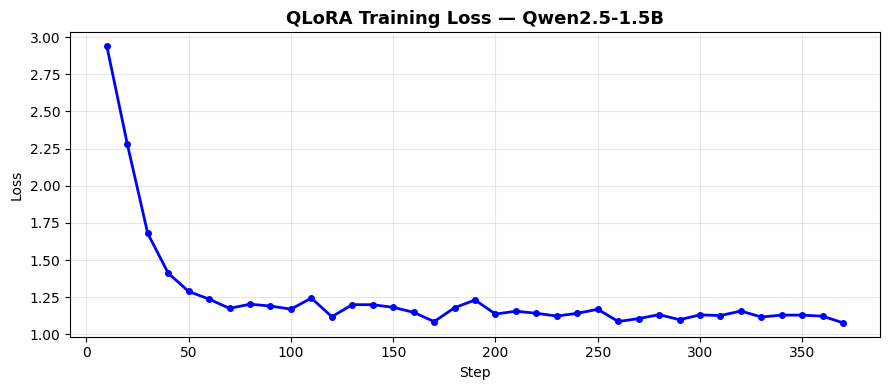

In [13]:
log    = trainer.state.log_history
steps  = [x["step"] for x in log if "loss" in x]
losses = [x["loss"]  for x in log if "loss" in x]

plt.figure(figsize=(9, 4))
plt.plot(steps, losses, "b-o", lw=2, markersize=4)
plt.title("QLoRA Training Loss — Qwen2.5-1.5B", fontsize=13, fontweight="bold")
plt.xlabel("Step"); plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=120)
plt.show()


## PHASE 4 — AFTER Fine-Tuning: Side-by-Side

In [14]:
print("FINE-TUNED MODEL SMOKE TEST:")
print("-"*60)
_smoke_h2 = [
    {"role": "system", "content": make_system_msg(_p)},
    {"role": "user",   "content": "Doctor: What is your name and how old are you?"},
]
resp_ft = generate(ft_model, _smoke_h2, max_new_tokens=80)
print(f"Patient: {_p['name']}, {_p['age']}y")
print(f"Response: {resp_ft}")
print("-"*60)

print("\nRunning AFTER fine-tuning evaluation...")
after_results = []
for i, (pat, qs) in enumerate(zip(EVAL_PATIENTS_BA, EVAL_QUESTIONS_BA)):
    print(f"  [{i+1}/3] {pat['name']}")
    after_results.append({"patient": pat, "qa": run_eval(ft_model, pat, qs)})

print("\n" + "#"*70)
print(" BEFORE vs AFTER — Side-by-Side")
print("#"*70)

for b, a in zip(before_results, after_results):
    p = b["patient"]
    print(f"\n{'='*70}")
    print(f"  {p['name']}, {p['age']}y {p['gender']}  |  Disease: {p['disease']}")
    print(f"{'='*70}")
    for (q, rb), (_, ra) in zip(b["qa"], a["qa"]):
        rb = rb if rb else "[empty]"
        ra = ra if ra else "[empty]"
        print(f"  Dr: {q}")
        print(f"  BEFORE : {textwrap.fill(rb, 58, subsequent_indent='           ')}")
        print(f"  AFTER  : {textwrap.fill(ra, 58, subsequent_indent='           ')}")
        print()


FINE-TUNED MODEL SMOKE TEST:
------------------------------------------------------------
Patient: Brian Holt, 34y
Response: My name is Bryan Holt and i'm 36 years old now.
------------------------------------------------------------

Running AFTER fine-tuning evaluation...
  [1/3] Victor Perry
  [2/3] Joshua Edwards
  [3/3] Kayla Baker

######################################################################
 BEFORE vs AFTER — Side-by-Side
######################################################################

  Victor Perry, 41y Male  |  Disease: Breast Cancer
  Dr: What is your name and how old are you?
  BEFORE : My name is Victor Perry and I am 41 years old.
  AFTER  : My name is Victor Perry and I am 41 years old.

  Dr: What brings you in today?
  BEFORE : Today, I have been experiencing breast pain along with
           some nipple changes. These symptoms have been
           ongoing since yesterday evening when they first
           appeared. Additionally, there seems to be a
  

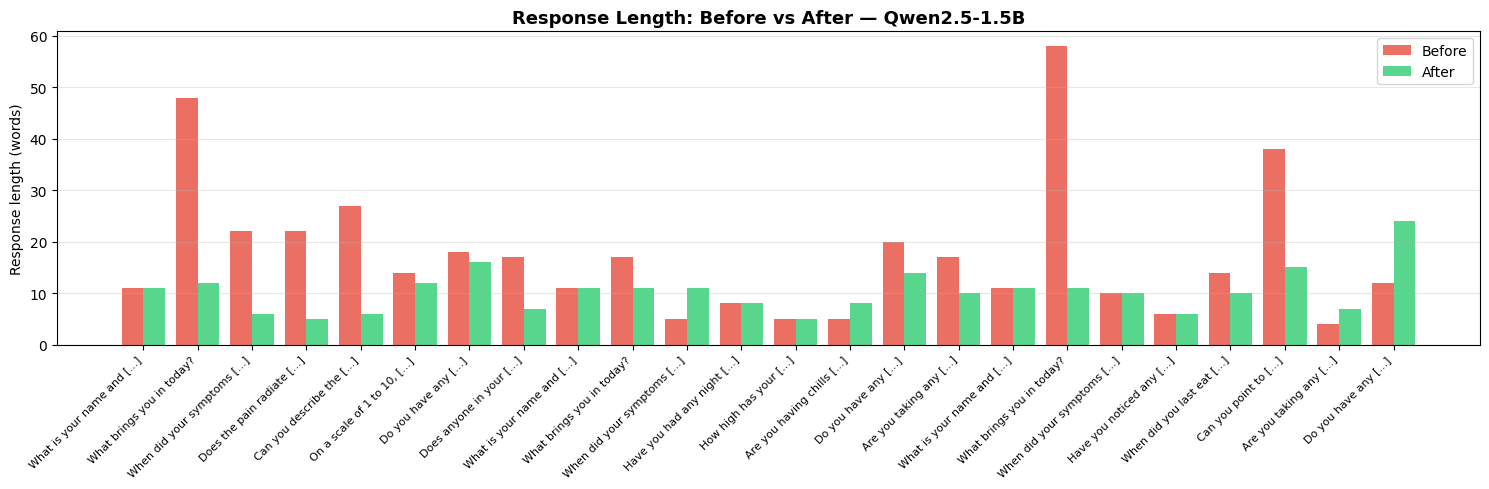

Avg — Before: 17.5w  After: 10.3w


In [15]:
b_lens, a_lens, xlabels = [], [], []
for bs, as_ in zip(before_results, after_results):
    for (q, rb), (_, ra) in zip(bs["qa"], as_["qa"]):
        b_lens.append(len(rb.split()))
        a_lens.append(len(ra.split()))
        xlabels.append(textwrap.shorten(q, 28))

x = range(len(xlabels))
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar([i-0.2 for i in x], b_lens, 0.4, label="Before", color="#e74c3c", alpha=0.8)
ax.bar([i+0.2 for i in x], a_lens, 0.4, label="After",  color="#2ecc71", alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Response length (words)")
ax.set_title("Response Length: Before vs After — Qwen2.5-1.5B", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("before_after_lengths.png", dpi=120)
plt.show()
print(f"Avg — Before: {sum(b_lens)/len(b_lens):.1f}w  After: {sum(a_lens)/len(a_lens):.1f}w")


## PHASE 5 — Robust Evaluation Benchmark

In [16]:
# ---------------------------------------------------------------------------
# Robust evaluation benchmark — 6 complementary metrics:
#
#  1. Identity recall          — does model say correct name + age?
#  2. Symptom coverage (F1)    — precision/recall against RAG canonical set
#  3. Diagnosis non-leakage    — NER-style keyword check for disease names
#  4. BLEU-1/2                 — n-gram overlap vs. reference symptom vocab
#  5. Response conciseness     — word count within 10-40 word target band
#  6. Factual consistency      — does response contradict assigned symptoms?
#
# Metrics 2 and 6 use the RAG KB as the gold standard, which is what
# makes hallucination detectable: any symptom claimed by the model that
# is not in the canonical set counts against factual consistency.
# ---------------------------------------------------------------------------

from nltk.tokenize import word_tokenize

SMOOTHER = SmoothingFunction().method1

DISEASE_LEAK_PATTERNS = {
    "Pneumonia":                                ["pneumonia", "consolidation"],
    "GERD":                                     ["gerd", "reflux", "gastroesophageal"],
    "Bronchitis":                               ["bronchitis"],
    "Influenza":                                ["influenza", "flu"],
    "Panic attack":                             ["panic attack", "panic disorder"],
    "Stable angina":                            ["angina", "coronary artery disease"],
    "Unstable angina":                          ["angina", "coronary artery disease", "acs"],
    "Bronchospasm / Acute Asthma Exacerbation": ["asthma", "bronchospasm", "asthmatic"],
    "Pulmonary embolism":                       ["pulmonary embolism", "blood clot", "pe"],
    "Cluster headache":                         ["cluster headache"],
}


def _tokenize(text: str) -> list:
    return [w.lower() for w in word_tokenize(text) if w.isalpha() and w.lower() not in STOPWORDS]


# Symptom-question detector — F1 is only meaningful when the doctor
# is actually asking about symptoms, not name/history/admin questions.
_SYMPTOM_Q_PATTERNS = re.compile(
    r"symptom|pain|cough|fever|breath|feel|ache|hurt|nausea|dizz|"
    r"chest|describe|main complaint|brings you|what.*wrong|how.*long|"
    r"worse|better|started|onset|trigger|when did|any other",
    re.I
)

def score_response(resp: str, patient: dict, question: str) -> dict:
    rl   = resp.lower()
    toks = _tokenize(resp)

    # 1. Identity recall — only scored on identity questions
    id_ok = None
    if re.search(r"\bname\b|\bhow old\b|\bage\b", question, re.I):
        id_ok = (patient["first"].lower() in rl) and (str(patient["age"]) in rl)

    # 2. Symptom coverage F1
    # Only scored when the question is a symptom-probing question.
    # Averaging F1 over name/history/admin turns artificially deflates it
    # because those turns correctly contain zero symptom vocabulary.
    canonical   = patient.get("canonical_symptoms", [])
    assigned    = [s.strip() for s in patient.get("symptoms", "").split(",") if s.strip()]
    ref_phrases = list(dict.fromkeys(assigned + canonical))

    is_symptom_q = bool(_SYMPTOM_Q_PATTERNS.search(question))

    if ref_phrases and is_symptom_q:
        resp_words = set(toks)
        covered = sum(
            1 for phrase in ref_phrases
            if set(_tokenize(phrase)) & resp_words
        )
        f1 = covered / max(len(ref_phrases), 1)
        precision = f1
        recall    = f1
    else:
        f1 = precision = recall = None  # not applicable for this question type

    # 3. Diagnosis non-leakage — word-boundary match (not substring)
    # "pe" as substring would match "people", "deep" etc. — use \b guards.
    leak_kws = DISEASE_LEAK_PATTERNS.get(
        patient["disease"],
        [w.lower() for w in patient["disease"].split() if len(w) > 4]
    )
    no_leak = not any(
        re.search(r"\b" + re.escape(kw) + r"\b", rl)
        for kw in leak_kws
    )

    # 4. ROUGE-L (replaces BLEU — more appropriate for short conversational text)
    # ROUGE-L measures longest common subsequence between response and
    # the canonical symptom description, normalised by length.
    def rouge_l(hyp_toks, ref_toks):
        if not hyp_toks or not ref_toks:
            return 0.0
        m, n = len(ref_toks), len(hyp_toks)
        dp = [[0]*(n+1) for _ in range(m+1)]
        for i in range(1, m+1):
            for j in range(1, n+1):
                dp[i][j] = dp[i-1][j-1]+1 if ref_toks[i-1]==hyp_toks[j-1] else max(dp[i-1][j], dp[i][j-1])
        lcs = dp[m][n]
        p = lcs / max(n, 1)
        r = lcs / max(m, 1)
        return 2*p*r / max(p+r, 1e-9)

    ref_toks_flat = _tokenize(" ".join(canonical)) if canonical else toks
    rouge = rouge_l(toks, ref_toks_flat)

    # 5. Conciseness — 8-50 words is appropriate for conversational patient answers
    wc = len(resp.split())
    concise = 1.0 if 8 <= wc <= 50 else (0.5 if 4 <= wc <= 70 else 0.0)

    # 6. Factual consistency — symptom-vocab filtered hallucination check
    SYMPTOM_VOCAB = {
        "fever","cough","pain","ache","nausea","vomit","tremor","trembling",
        "wheeze","wheezi","dyspnoea","fatigue","dizzi","headache","blurr",
        "thirst","urinat","sweat","palpitat","stiffness","rigidity","shuffl",
        "regurgit","heartburn","constipat","diarrhoea","bloat","cramp",
        "breathless","chest","abdomen","abdomi","throat","vision","hearing",
        "swollen","swelling","discharg","bleed","rash","itching","weakness",
        "paralysis","seizure","confusion","anxiety","insomnia","syncope",
    }
    ref_all_toks = set(w for p in ref_phrases for w in _tokenize(p)) if ref_phrases else set()
    hallu_toks = {
        t for t in toks
        if any(t.startswith(sv) for sv in SYMPTOM_VOCAB)
        and t not in ref_all_toks
    }
    factual_ok = len(hallu_toks) == 0

    return {
        "id_ok":        id_ok,
        "sym_f1":       round(f1, 3)       if f1       is not None else None,
        "sym_precision":round(precision, 3) if precision is not None else None,
        "sym_recall":   round(recall, 3)    if recall   is not None else None,
        "is_symptom_q": is_symptom_q,
        "no_leak":      no_leak,
        "rouge_l":      round(rouge, 3),
        "concise":      concise,
        "factual_ok":   factual_ok,
        "length":       wc,
    }


print("Scorer loaded. Metrics: identity, sym_f1, no_leak, bleu1/2, conciseness, factual_ok")


Scorer loaded. Metrics: identity, sym_f1, no_leak, bleu1/2, conciseness, factual_ok


In [17]:
# ---------------------------------------------------------------------------
# End-to-end evaluation runner.
# Generates N fresh Synthea patients, builds a dynamic question set for each,
# runs a full multi-turn dialogue, and scores every response.
# ---------------------------------------------------------------------------

def run_auto_eval(model_obj, n: int = 5) -> list:
    results = []
    for i in range(n):
        patient   = synthea_patient()
        questions = generate_doctor_questions(patient, n_symptom_qs=4)

        history      = (
            [{"role": "system", "content": make_system_msg(patient)}]
            + make_seed_turns(patient)
        )
        symptom_log  = {}
        case_scores  = []

        for q in questions:
            rag_ctx = rag_retrieve(patient["disease"], q)
            history.append({"role": "user", "content": f"Doctor: {q}"})
            resp = generate_aligned(model_obj, history, patient, symptom_log,
                                    rag_context=rag_ctx, max_new_tokens=120)
            history.append({"role": "assistant", "content": resp})
            symptom_log = update_symptom_log(symptom_log, q, resp)

            s = score_response(resp, patient, q)
            s["question"] = q
            s["response"] = resp
            case_scores.append(s)

        results.append({
            "patient":  patient,
            "scores":   case_scores,
            "history":  history,
        })
        print(f"  [{i+1}/{n}] {patient['name']}, {patient['age']}y — {patient['disease']}")

    return results


print("Running evaluation on fine-tuned model (5 cases)...")
eval_results = run_auto_eval(ft_model, n=5)
print("\nDone")


Running evaluation on fine-tuned model (5 cases)...
  [1/5] Raymond Brown, 33y — Edward Syndrome
  [2/5] Alicia Pham, 62y — Volvulus
  [3/5] Jim Nelson, 60y — Polycythemia Vera
  [4/5] Crystal Butler, 47y — Hypercholesterolemia
  [5/5] Kelsey Smith, 33y — Lung Contusion

Done


In [18]:
print("\n" + "#"*70)
print(" FULL EVALUATION RESULTS")
print("#"*70)

for res in eval_results:
    p = res["patient"]
    print(f"\n{'='*70}")
    print(f"  {p['name']}, {p['age']}y {p['gender']}  |  {p['disease']}")
    print(f"  Vitals : {p['vitals']['BP']} · {p['vitals']['HR']} · {p['vitals']['Temp']} · {p['vitals']['SpO2']}")
    print(f"  Onset  : {p['onset']}")
    print(f"{'─'*70}")
    for s in res["scores"]:
        leak_tag   = " [LEAK]" if not s["no_leak"] else ""
        hallu_tag  = " [HALLU]" if not s["factual_ok"] else ""
        id_tag     = "" if s["id_ok"] is None else (" [ID-OK]" if s["id_ok"] else " [ID-MISS]")
        r = s["response"] if s["response"] else "[empty]"
        print(f"  Dr: {textwrap.shorten(s['question'], 50)}")
        print(f"  Pt: {textwrap.fill(r, 62, subsequent_indent='      ')}")
        f1_str  = f"F1={s['sym_f1']:.2f}" if s['sym_f1'] is not None else "F1=n/a"
        print(f"      len={s['length']}w  {f1_str}  "
              f"ROUGE-L={s['rouge_l']:.2f}  concise={s['concise']:.1f}"
              f"{leak_tag}{hallu_tag}{id_tag}")
        print()



######################################################################
 FULL EVALUATION RESULTS
######################################################################

  Raymond Brown, 33y Male  |  Edward Syndrome
  Vitals : 123/78 mmHg · 61 bpm · 36.4C · 98%
  Onset  : started about 3 days ago
──────────────────────────────────────────────────────────────────────
  Dr: What is your name and how old are you?
  Pt: My name is Raymond Brown and I am 33 years old.
      len=11w  F1=n/a  ROUGE-L=0.00  concise=1.0 [ID-OK]

  Dr: What brings you in today?
  Pt: It's been a few weeks now since I noticed some developmental
      issues like slow speech and difficulty speaking clearly.
      len=19w  F1=0.20  ROUGE-L=0.09  concise=1.0

  Dr: When did your symptoms first start?
  Pt: They have been going on for about three days now.
      len=10w  F1=0.00  ROUGE-L=0.00  concise=1.0

  Dr: Does anything make it better or worse?
  Pt: No, everything seems to be getting worse over time.
      len=

Metric                                 Value  Notes
-----------------------------------------------------------------
Identity recall                       100.0%  (name+age questions only)
Symptom F1 (symptom-Qs only)            8.0%  (19/43 turns scored)
No diagnosis leak                     100.0%  (word-boundary match)
Factual consistency                    93.0%  (symptom-vocab filter)
Conciseness (8-50w band)               83.7%
ROUGE-L                                0.024  (replaces BLEU)
Avg response length                    11.8w


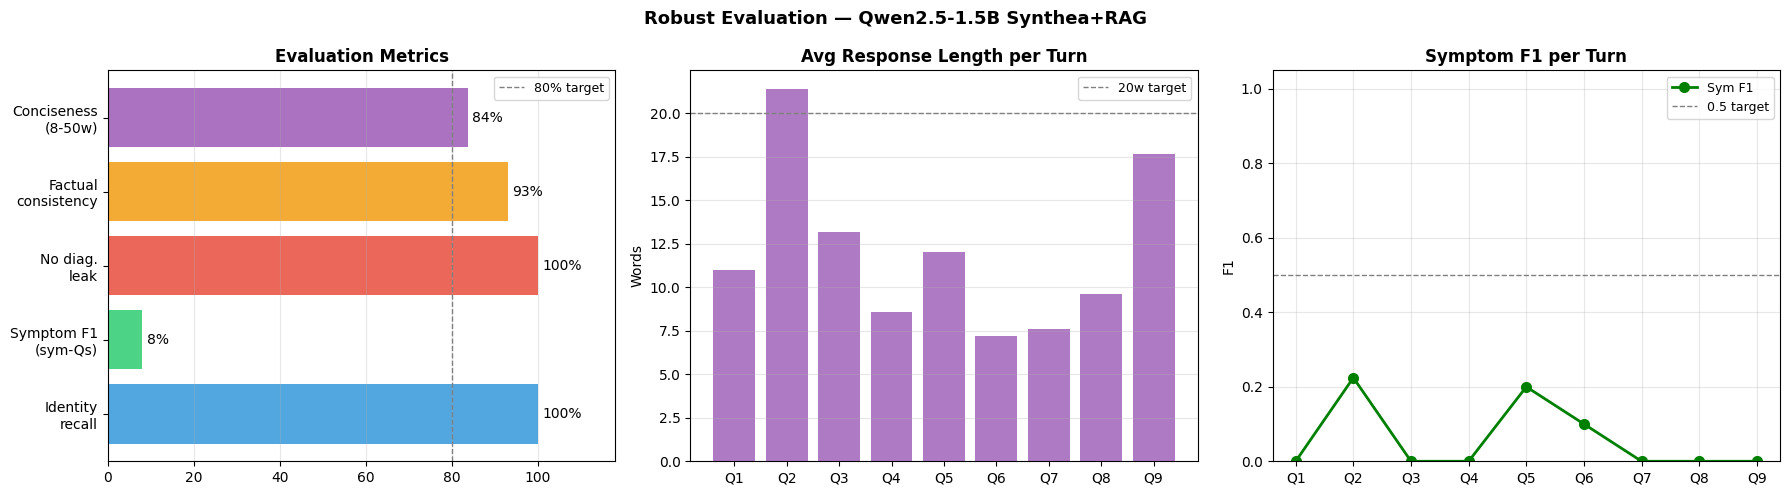

Avg response length : 11.8 words


In [19]:
flat = [s for r in eval_results for s in r["scores"]]

avg_len    = sum(s["length"]  for s in flat) / len(flat)
# F1: only average over turns where it was applicable (symptom questions)
f1_scores  = [s["sym_f1"] for s in flat if s["sym_f1"] is not None]
avg_f1     = sum(f1_scores) / max(len(f1_scores), 1)
avg_rouge  = sum(s["rouge_l"] for s in flat) / len(flat)
no_leak_rt = sum(1 for s in flat if s["no_leak"])    / len(flat)
factual_rt = sum(1 for s in flat if s["factual_ok"]) / len(flat)
concise_rt = sum(s["concise"] for s in flat)         / len(flat)
id_scores  = [s for s in flat if s["id_ok"] is not None]
id_ok_rt   = sum(1 for s in id_scores if s["id_ok"]) / max(len(id_scores), 1)
sym_q_cnt  = sum(1 for s in flat if s["is_symptom_q"])

print(f"{'Metric':<35} {'Value':>8}  Notes")
print("-"*65)
print(f"{'Identity recall':<35} {id_ok_rt*100:>7.1f}%  (name+age questions only)")
print(f"{'Symptom F1 (symptom-Qs only)':<35} {avg_f1*100:>7.1f}%  ({sym_q_cnt}/{len(flat)} turns scored)")
print(f"{'No diagnosis leak':<35} {no_leak_rt*100:>7.1f}%  (word-boundary match)")
print(f"{'Factual consistency':<35} {factual_rt*100:>7.1f}%  (symptom-vocab filter)")
print(f"{'Conciseness (8-50w band)':<35} {concise_rt*100:>7.1f}%")
print(f"{'ROUGE-L':<35} {avg_rouge:>8.3f}  (replaces BLEU)")
print(f"{'Avg response length':<35} {avg_len:>7.1f}w")

# ── Plot ─────────────────────────────────────────────────────────────────
bar_metrics = {
    "Identity\nrecall":      id_ok_rt  * 100,
    "Symptom F1\n(sym-Qs)":  avg_f1    * 100,
    "No diag.\nleak":        no_leak_rt* 100,
    "Factual\nconsistency":  factual_rt* 100,
    "Conciseness\n(8-50w)":  concise_rt* 100,
}
bar_colors = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12", "#9b59b6"]

# Compute n_turns first, then build per_turn to the same length — avoids
# the shape mismatch when actual turns (e.g. 9) exceeds the hardcoded 8.
n_turns     = max(len(r["scores"]) for r in eval_results)
turn_labels = [f"Q{t+1}" for t in range(n_turns)]
per_turn = [
    sum(r["scores"][t]["length"] for r in eval_results if t < len(r["scores"])) /
    max(sum(1 for r in eval_results if t < len(r["scores"])), 1)
    for t in range(n_turns)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: bar chart of all metrics
axes[0].barh(list(bar_metrics), list(bar_metrics.values()),
             color=bar_colors, alpha=0.85)
for i, v in enumerate(bar_metrics.values()):
    axes[0].text(v+1, i, f"{v:.0f}%", va="center", fontsize=10)
axes[0].axvline(80, color="gray", ls="--", lw=1, label="80% target")
axes[0].set_xlim(0, 118)
axes[0].legend(fontsize=9)
axes[0].set_title("Evaluation Metrics", fontsize=12, fontweight="bold")
axes[0].grid(True, alpha=0.3, axis="x")

# Middle: per-turn response length
axes[1].bar(turn_labels, per_turn, color="#9b59b6", alpha=0.8)
axes[1].axhline(20, color="gray", ls="--", lw=1, label="20w target")
axes[1].set_title("Avg Response Length per Turn", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Words")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis="y")

# Right: per-turn F1
per_turn_f1 = []
for t in range(n_turns):
    vals = [r["scores"][t]["sym_f1"] for r in eval_results
            if t < len(r["scores"]) and r["scores"][t]["sym_f1"] is not None]
    per_turn_f1.append(sum(vals)/max(len(vals),1) if vals else 0.0)
axes[2].plot(turn_labels, per_turn_f1, "go-", lw=2, markersize=7, label="Sym F1")
axes[2].set_ylim(0, 1.05)
axes[2].set_title("Symptom F1 per Turn", fontsize=12, fontweight="bold")
axes[2].set_ylabel("F1")
axes[2].axhline(0.5, color="gray", ls="--", lw=1, label="0.5 target")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle("Robust Evaluation — Qwen2.5-1.5B Synthea+RAG",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eval_metrics.png", dpi=120)
plt.show()

print(f"Avg response length : {avg_len:.1f} words")


## PHASE 6 — Interactive Chat

In [21]:
# ---------------------------------------------------------------------------
# Disease Engine
# Tracks state across the conversation:
#   - which canonical symptoms have been revealed by the patient
#   - a "revealed_count" that drives progressive symptom exposure
#   - after each patient answer, scans for symptom keywords mentioned
#     and marks them as revealed in the engine state
# This makes the conversation dynamic — the doctor progressively uncovers
# the symptom picture rather than getting everything upfront.
# ---------------------------------------------------------------------------

class DiseaseEngine:
    def __init__(self, patient: dict):
        self.disease    = patient["disease"]
        self.canonical  = list(patient["canonical_symptoms"])
        self.treatments = list(patient.get("treatments", []))
        self.revealed   = set()        # symptoms confirmed by patient answers
        self.turn_count = 0

    def update(self, patient_response: str):
        """
        Scan the patient response for symptom keywords.
        Mark any canonical symptoms that appear (partial match) as revealed.
        """
        self.turn_count += 1
        rl = patient_response.lower()
        for sym in self.canonical:
            sym_toks = [w.lower() for w in sym.split() if len(w) > 3]
            if any(tok in rl for tok in sym_toks):
                self.revealed.add(sym)

    def revealed_summary(self) -> str:
        if not self.revealed:
            return "No symptoms confirmed yet."
        return "Confirmed so far: " + ", ".join(sorted(self.revealed))

    def coverage(self) -> float:
        return len(self.revealed) / max(len(self.canonical), 1)

    def reveal_full(self) -> str:
        lines = [
            f"  Disease    : {self.disease}",
            f"  Canonical symptoms ({len(self.canonical)}):",
        ]
        for s in self.canonical:
            tick = "+" if s in self.revealed else " "
            lines.append(f"    [{tick}] {s}")
        if self.treatments:
            lines.append(f"  Treatments : {', '.join(self.treatments[:4])}")
        lines.append(f"  Coverage   : {len(self.revealed)}/{len(self.canonical)} "
                     f"symptoms revealed ({self.coverage()*100:.0f}%)")
        return "\n".join(lines)


# ---------------------------------------------------------------------------
# Interactive Chat — implements the full 7-step flow:
#
#  1. Case Generator       -> synthea_patient() picks from 400 KB diseases
#  2. Patient created      -> disease + symptoms embedded in patient dict
#  3. Doctor asks question -> input() from user
#  4. RAG retrieves info   -> rag_retrieve(disease, question) per turn
#  5. Fine-tuned LLM       -> generate_aligned() with RAG context injected
#  6. Disease engine       -> DiseaseEngine.update() after each response
#  7. Doctor diagnoses     -> "diagnose <name>" command
#     System reveals       -> DiseaseEngine.reveal_full() shows everything
# ---------------------------------------------------------------------------

def run_chat():
    # ── STEP 1 & 2: Case Generator / Patient created ───────────────────────
    patient = synthea_patient()
    engine  = DiseaseEngine(patient)
    questions = generate_doctor_questions(patient, n_symptom_qs=4)

    history     = (
        [{"role": "system", "content": make_system_msg(patient)}]
        + make_seed_turns(patient)
    )
    symptom_log = {}
    asked       = []
    q_idx       = 0

    print(f"\n{'='*65}")
    print(f" AI MEDICAL PATIENT SIMULATOR  (Qwen2.5-1.5B + RAG)")
    print(f"{'='*65}")
    print("  vitals              -- show patient vitals")
    print("  hint                -- show age/gender only")
    print("  suggest             -- show next suggested question")
    print("  revealed            -- show symptoms uncovered so far")
    print("  diagnose <disease>  -- submit your diagnosis")
    print("  new                 -- new random patient")
    print("  quit                -- exit")
    print(f"{'-'*65}")
    print("A new patient has arrived. Begin your consultation.")
    print(f"{'-'*65}")

    while True:
        try:
            raw = input("\nDoctor: ").strip()
        except EOFError:
            print("[Run interactively in Colab]"); return
        if not raw:
            continue

        if raw.lower() == "quit":
            print("Consultation ended."); break

        if raw.lower() == "hint":
            print(f"  [{patient['age']}-year-old {patient['gender']}]")
            continue

        if raw.lower() == "vitals":
            v = patient["vitals"]
            print(f"  BP:{v['BP']}  HR:{v['HR']}  Temp:{v['Temp']}  "
                  f"SpO2:{v['SpO2']}  RR:{v.get('RR','?')}  Pain:{v.get('Pain','?')}")
            continue

        if raw.lower() == "suggest":
            if q_idx < len(questions):
                print(f"  Suggested: {questions[q_idx]}")
            else:
                print("  No more suggested questions.")
            continue

        if raw.lower() == "revealed":
            print(f"  {engine.revealed_summary()}")
            print(f"  Coverage: {engine.coverage()*100:.0f}% of canonical symptoms")
            continue

        if raw.lower() == "new":
            run_chat(); return

        # ── STEP 7 & 8: Doctor diagnoses / System reveals ──────────────────
        if raw.lower().startswith("diagnose "):
            sub   = raw[9:].strip()
            corr  = patient["disease"].lower()
            sub_w = set(sub.lower().split())
            cor_w = set(corr.split())

            if sub.lower() == corr:
                result = "CORRECT"
            elif sub_w & cor_w:
                result = "CLOSE"
            else:
                result = "INCORRECT"

            print(f"\n{'='*65}")
            print(f" DIAGNOSIS REPORT")
            print(f"{'='*65}")
            print(f"  Your diagnosis : {sub}")
            print(f"  Result         : {result}")
            print(f"  Questions asked: {len(asked)}")
            print()
            print(" FULL DISEASE REVEAL:")
            print(engine.reveal_full())
            print(f"{'='*65}")
            break

        # ── STEP 3: Doctor asks question ────────────────────────────────────
        asked.append(raw)
        if q_idx < len(questions) and raw == questions[q_idx]:
            q_idx += 1

        # ── STEP 4: RAG retrieves disease-specific info ──────────────────────
        rag_ctx = rag_retrieve(patient["disease"], raw)

        # ── STEP 5: Fine-tuned LLM responds (with RAG context) ───────────────
        history.append({"role": "user", "content": f"Doctor: {raw}"})
        resp = generate_aligned(
            ft_model, history, patient, symptom_log,
            rag_context=rag_ctx, max_new_tokens=120
        )
        history.append({"role": "assistant", "content": resp})

        # ── STEP 6: Disease engine updates revealed symptoms ─────────────────
        engine.update(resp)
        symptom_log = update_symptom_log(symptom_log, raw, resp)

        r_disp = resp if resp else "[no response -- try rephrasing]"
        print(f"\nPatient: {textwrap.fill(r_disp, 60, subsequent_indent='         ')}")


run_chat()



 AI MEDICAL PATIENT SIMULATOR  (Qwen2.5-1.5B + RAG)
  vitals              -- show patient vitals
  hint                -- show age/gender only
  suggest             -- show next suggested question
  revealed            -- show symptoms uncovered so far
  diagnose <disease>  -- submit your diagnosis
  new                 -- new random patient
  quit                -- exit
-----------------------------------------------------------------
A new patient has arrived. Begin your consultation.
-----------------------------------------------------------------

Doctor: good morning, what is your name?

Patient: My name is David Spencer and I am 53 years old.

Doctor: vitals
  BP:108/74 mmHg  HR:73 bpm  Temp:36.5C  SpO2:97%  RR:16 breaths/min  Pain:2/10

Doctor: why have you came here?

Patient: Well, when I woke up yesterday morning, I felt a bit heavy
         and tight all over. It's like there was pressure
         everywhere. And then, I noticed some swelling in my
         arms and legs t

## Save

In [22]:
from google.colab import drive
drive.mount('/content/drive')

ADAPTER = "/content/drive/MyDrive/qwen-patient-adapter"
ft_model.save_pretrained(ADAPTER)
tokenizer.save_pretrained(ADAPTER)
import os
mb = sum(os.path.getsize(os.path.join(ADAPTER,f)) for f in os.listdir(ADAPTER))/1024**2
print(f"Saved -> {ADAPTER} ({mb:.1f} MB)")

print("""
Reload:
  from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
  from peft import PeftModel
  import torch

  bnb  = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',
                             bnb_4bit_compute_dtype=torch.bfloat16)
  base = AutoModelForCausalLM.from_pretrained('Qwen/Qwen2.5-1.5B-Instruct',
                                               quantization_config=bnb, device_map='auto')
  tok  = AutoTokenizer.from_pretrained('./qwen-patient-adapter')
  mdl  = PeftModel.from_pretrained(base, './qwen-patient-adapter').eval()
""")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved -> /content/drive/MyDrive/qwen-patient-adapter (37.2 MB)

Reload:
  from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
  from peft import PeftModel
  import torch

  bnb  = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',
                             bnb_4bit_compute_dtype=torch.bfloat16)
  base = AutoModelForCausalLM.from_pretrained('Qwen/Qwen2.5-1.5B-Instruct',
                                               quantization_config=bnb, device_map='auto')
  tok  = AutoTokenizer.from_pretrained('./qwen-patient-adapter')
  mdl  = PeftModel.from_pretrained(base, './qwen-patient-adapter').eval()

